# Customer Personality Analysis
Mahdi Ghadami

customer personality dataset containing demographic information, spending habits, promotional responses, and purchasing behaviors.
 we will conduct hypothesis tests to uncover insights about customer behaviors and characteristics.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##  Data Exploration and Visualization

 Before performing hypothesis tests, it’s essential to understand the dataset’s structure and the relationships between variables. Begin by exploring the data through appropriate visualizations.

### Data Inspection

In [5]:
df = pd.read_csv(path + '/marketing_campaign.csv', sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

* null values:

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum().sum()

0

In [11]:
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [12]:
df.drop(['Z_Revenue','Z_CostContact'],axis=1,inplace=True) 

In [13]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [14]:
df['Marital_Status']=df['Marital_Status'].replace({'Alone':'Single','YOLO':'Single','Absurd':'Single'})

In [15]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [16]:
df['Education'] = df['Education'].replace({'2n Cycle':'UG', 'Basic':'UG'})

In [17]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Visualization

In [19]:
#Selecting numerical features
numerical_data = df.select_dtypes(include='number')
#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 24 numerical features: 

['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


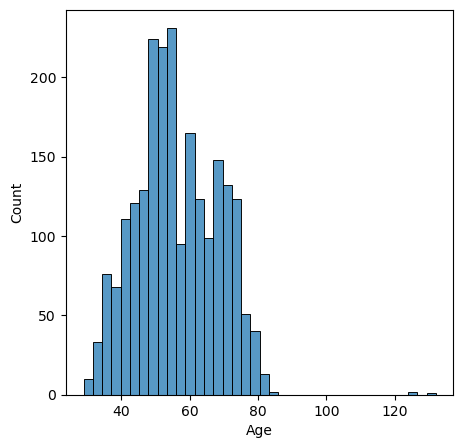

In [20]:
df['Age'] = 2025-df['Year_Birth']
plt.figure(figsize=(5,5))
sns.histplot(df['Age'])
plt.show()

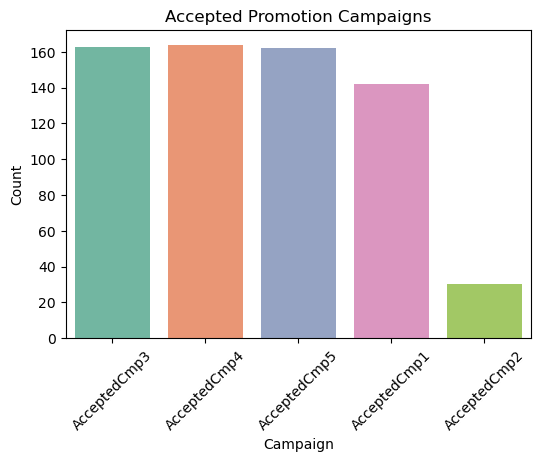

In [21]:
promotion = df.loc[:, ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2']]
promotion_tot = promotion.sum()

promotion_df = promotion_tot.reset_index()
promotion_df.columns = ['Campaign', 'Count']


plt.figure(figsize=(6,4))
sns.barplot(x='Campaign', y='Count', data=promotion_df, palette='Set2')

plt.xticks(rotation=45)

plt.title("Accepted Promotion Campaigns")
plt.xlabel("Campaign")
plt.ylabel("Count")

plt.show()

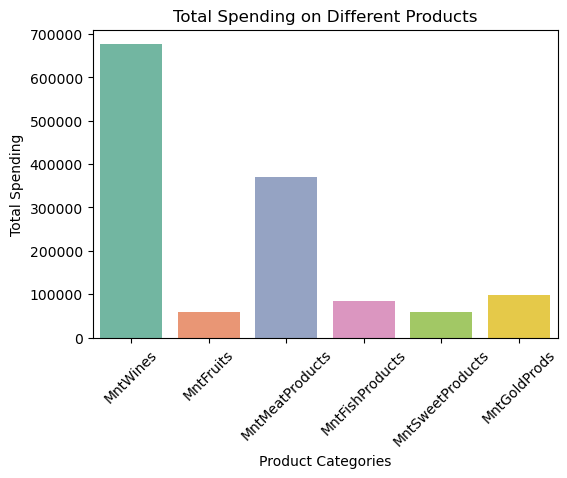

In [22]:
products = df.loc[:, ['MntWines', 'MntFruits', 'MntMeatProducts', 
                      'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]
products_tot = products.sum()

# Create a bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=products_tot.index, y=products_tot.values, palette="Set2")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.xlabel("Product Categories")
plt.ylabel("Total Spending")
plt.title("Total Spending on Different Products")

plt.show()

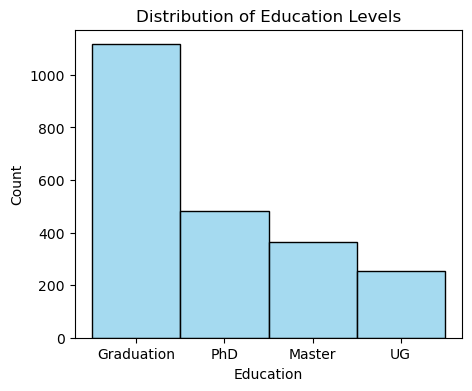

In [23]:
plt.figure(figsize=(5, 4))
sns.histplot(df['Education'], color="skyblue")
plt.title("Distribution of Education Levels")
plt.show()

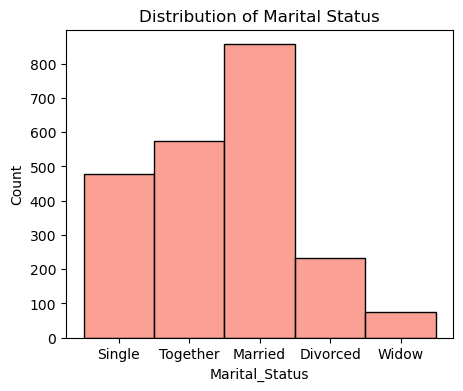

In [24]:
plt.figure(figsize=(5, 4))
sns.histplot(df['Marital_Status'], color="salmon")
plt.title("Distribution of Marital Status")
plt.show()

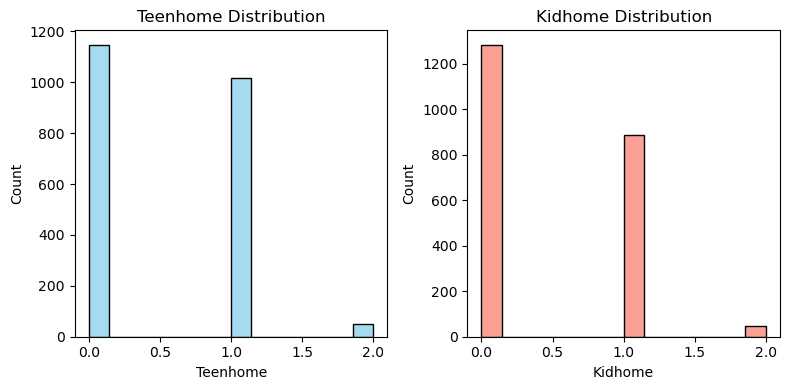

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))


sns.histplot(df['Teenhome'], ax=axes[0], color="skyblue")
axes[0].set_title("Teenhome Distribution")


sns.histplot(df['Kidhome'], ax=axes[1], color="salmon")
axes[1].set_title("Kidhome Distribution")

plt.tight_layout()
plt.show()

## Hypothesis Testing

### Do customers from different education levels have different income levels?

In [28]:
import scipy.stats as stats

UG_income = df[df['Education'] == 'UG']['Income']
Master_income = df[df['Education'] == 'Master']['Income']
PhD_income = df[df['Education'] == 'PhD']['Income']
Graduation_income = df[df['Education'] == 'Graduation']['Income']

stat, p = stats.kruskal(UG_income, Master_income, PhD_income, Graduation_income)

print(f"Kruskal-Wallis H-statistic: {stat}")
print(f"P-value: {p}")

Kruskal-Wallis H-statistic: 71.99833577587502
P-value: 1.5932077492910976e-15


### Is there a significant difference in spending before and after a marketing campaign?

create features for total spents and total campaign acceptions:

In [31]:
df['Total_spents'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Total_AcceptedCmps'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response']
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']

In [32]:
from scipy.stats import mannwhitneyu

# Before Campaign
before_campaign = df[df['Total_AcceptedCmps'] == 0]

# After Campaign
after_campaign = df[df['Total_AcceptedCmps'] > 0]

# Extract the spending data
spending_before = before_campaign['Total_spents']
spending_after = after_campaign['Total_spents']

# Perform Mann-Whitney U Test
stat, p_value = mannwhitneyu(spending_before, spending_after)

print(f"Mann-Whitney U Test result:")
print(f"U statistic: {stat}")
print(f"P-value: {p_value}")

Mann-Whitney U Test result:
U statistic: 255968.0
P-value: 1.300457942953344e-66


### Do customers with children spend differently than those without children?

In [34]:
df['Total_children'] = df['Teenhome'] + df['Kidhome']

is_parents_spents = df[df['Total_children'] == 0]['Total_spents']
not_parents_spents = df[df['Total_children'] != 0]['Total_spents']

In [35]:
stat, p_value = stats.mannwhitneyu(is_parents_spents, not_parents_spents, alternative='two-sided')

print("Mann-Whitney U-statistic:", stat)
print("P-value:", p_value)

Mann-Whitney U-statistic: 798765.0
P-value: 3.7522691035343634e-106


### Is there a significant difference in customer satisfaction across multiple product categories?

In [37]:
stat, p_value = stats.friedmanchisquare(df['MntWines'], 
                                        df['MntFruits'], 
                                        df['MntMeatProducts'],
                                        df['MntFishProducts'], 
                                        df['MntSweetProducts'], 
                                        df['MntGoldProds'])

print("Friedman Test Statistic:", stat)
print("P-value:", p_value)

Friedman Test Statistic: 5889.561490535339
P-value: 0.0


### Did the number of purchases change significantly after a new marketing strategy?

In [39]:
contingency_table = pd.crosstab(df['Total_AcceptedCmps'], df['Education'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

In [40]:
print("Chi-Square Statistic:", chi2)
print("P-Value:", p)

Chi-Square Statistic: 22.507501142376434
P-Value: 0.09517110155293661
